# Parkinson's disease demonstrations

This notebook demonstrates the four applicable tabular algorithms on one fixed Parkinson's train/test split: KNN, the improved decision tree, the improved random forest, and the improved neural network. The plots follow the final-project style: parameter-performance curves for the first three algorithms and a three-panel training-history figure for the neural network.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == 'demonstrations' else Path.cwd()
sys.path.insert(0, str(ROOT))

from algorithms.decision_tree import decision_tree_classifier
from algorithms.knn_implementation import KNN_classifier
from algorithms.neural_network import NeuralNetwork
from algorithms.random_forest import random_forest_classifier

DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results' / 'parkinsons'
FIGURES_DIR = ROOT / 'figures' / 'parkinsons'
SEED = 123

for path in (RESULTS_DIR, FIGURES_DIR):
    path.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'parkinsons_train.csv')
test = pd.read_csv(DATA_DIR / 'parkinsons_test.csv')
feature_names = list(train.columns[:-1])
attribute_types = ['numeric'] * len(feature_names)
X_train = train.iloc[:, :-1].to_numpy(float)
y_train = train.iloc[:, -1].to_numpy(bool)
X_test = test.iloc[:, :-1].to_numpy(float)
y_test = test.iloc[:, -1].to_numpy(bool)
print(f'train={X_train.shape}, test={X_test.shape}')

train=(156, 22), test=(39, 22)


In [2]:
def metrics(labels, predictions):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    tp = np.sum((labels == 1) & (predictions == 1))
    fp = np.sum((labels == 0) & (predictions == 1))
    fn = np.sum((labels == 1) & (predictions == 0))
    accuracy = np.mean(labels == predictions)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return float(accuracy), float(f1)

def plot_parameter_curve(performance, parameter, output_path):
    figure, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    for axis, metric, label in zip(axes, ('accuracy', 'f1'), ('Accuracy', 'F1')):
        axis.plot(performance[parameter], performance[f'{metric}_test'], marker='o')
        axis.set_xlabel(parameter)
        axis.set_ylabel(label)
        axis.grid(True)
    figure.tight_layout()
    figure.savefig(output_path, bbox_inches='tight')
    plt.show()


## K-nearest neighbors

The features are standardized because KNN uses Euclidean distance. The curve shows how the test set changes as `k` increases.

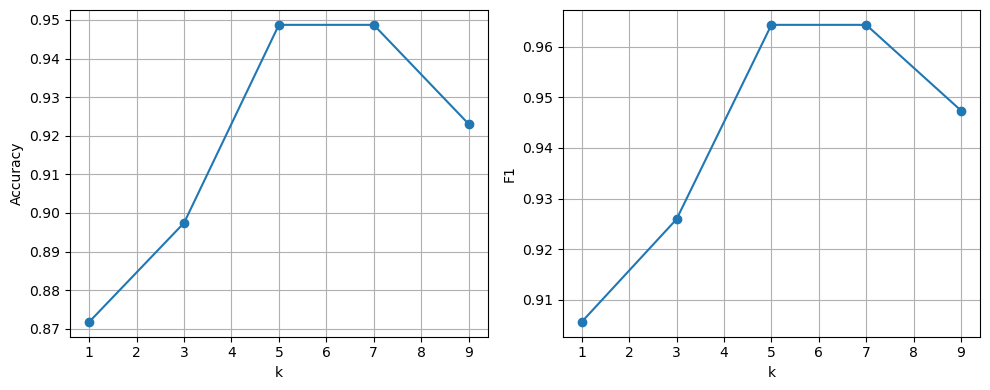

,k,accuracy_test,f1_test
0,1,0.871795,0.905660
1,3,0.897436,0.925926
2,5,0.948718,0.964286
3,7,0.948718,0.964286
4,9,0.923077,0.947368


In [3]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_rows = []
for k in (1, 3, 5, 7, 9):
    model = KNN_classifier(k).fit(X_train_scaled, y_train)
    accuracy, f1 = metrics(y_test, model.predict(X_test_scaled))
    knn_rows.append({'k': k, 'accuracy_test': accuracy, 'f1_test': f1})
knn_performance = pd.DataFrame(knn_rows)
(RESULTS_DIR / 'KNN').mkdir(exist_ok=True)
(FIGURES_DIR / 'KNN').mkdir(exist_ok=True)
knn_performance.to_csv(RESULTS_DIR / 'KNN' / 'performance.csv', index=False)
plot_parameter_curve(knn_performance, 'k', FIGURES_DIR / 'KNN' / 'performance_plot.png')
knn_performance

## Improved decision tree

The improved implementation adds `maximum_depth`, making the depth/bias–variance trade-off directly visible.

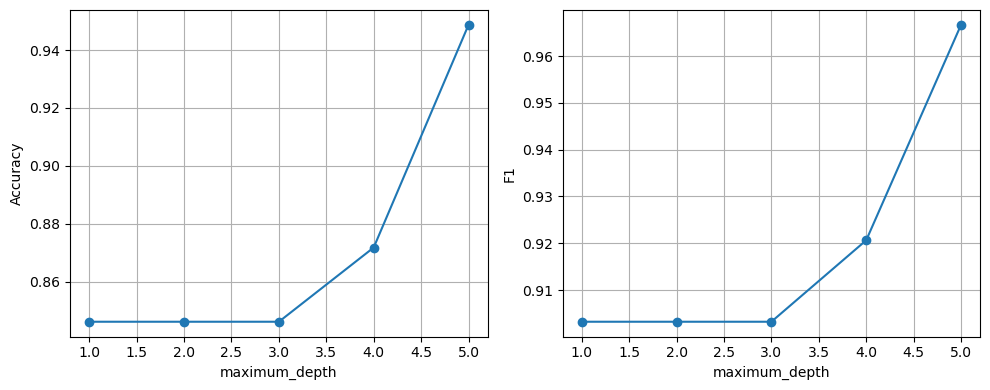

,maximum_depth,accuracy_test,f1_test
0,1,0.846154,0.903226
1,2,0.846154,0.903226
2,3,0.846154,0.903226
3,4,0.871795,0.920635
4,5,0.948718,0.966667


In [4]:
tree_rows = []
for depth in (1, 2, 3, 4, 5):
    model = decision_tree_classifier(
        split_criterion='information_gain',
        majority_class_threshold=1.0,
        minimum_size_for_split=10,
        minimum_split_quality_score=0.0,
        maximum_depth=depth,
        random_attribute_selection=False,
        random_seed=SEED,
    )
    model.fit(X_train, y_train, feature_names, attribute_types)
    accuracy, f1 = metrics(y_test, model.predict(X_test))
    tree_rows.append({'maximum_depth': depth, 'accuracy_test': accuracy, 'f1_test': f1})
tree_performance = pd.DataFrame(tree_rows)
(RESULTS_DIR / 'DecisionTree').mkdir(exist_ok=True)
(FIGURES_DIR / 'DecisionTree').mkdir(exist_ok=True)
tree_performance.to_csv(RESULTS_DIR / 'DecisionTree' / 'performance.csv', index=False)
plot_parameter_curve(tree_performance, 'maximum_depth', FIGURES_DIR / 'DecisionTree' / 'performance_plot.png')
tree_performance

## Improved random forest

The improved forest passes the configurable tree depth into every tree. To keep this notebook quick, the sweep uses a small number of trees.

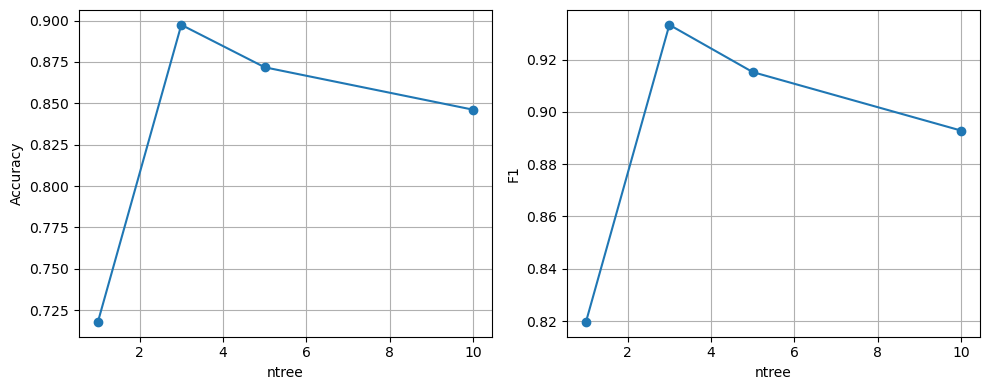

,ntree,accuracy_test,f1_test
0,1,0.717949,0.819672
1,3,0.897436,0.933333
2,5,0.871795,0.915254
3,10,0.846154,0.892857


In [5]:
forest_rows = []
for tree_count in (1, 3, 5, 10):
    model = random_forest_classifier(
        ntree=tree_count,
        split_criterion='information_gain',
        majority_class_threshold=1.0,
        minimum_size_for_split=10,
        minimum_split_quality_score=0.0,
        maximum_depth=5,
        random_seed=SEED,
    )
    model.fit(X_train, y_train, feature_names, attribute_types)
    accuracy, f1 = metrics(y_test, model.predict(X_test))
    forest_rows.append({'ntree': tree_count, 'accuracy_test': accuracy, 'f1_test': f1})
forest_performance = pd.DataFrame(forest_rows)
(RESULTS_DIR / 'RandomForest').mkdir(exist_ok=True)
(FIGURES_DIR / 'RandomForest').mkdir(exist_ok=True)
forest_performance.to_csv(RESULTS_DIR / 'RandomForest' / 'performance.csv', index=False)
plot_parameter_curve(forest_performance, 'ntree', FIGURES_DIR / 'RandomForest' / 'performance_plot.png')
forest_performance

## Improved neural network

The network uses standardized features, one hidden layer, L2 regularization, and the original-label API added in `ML_Algorithm_Compare`. The three panels match the final-project history figure.

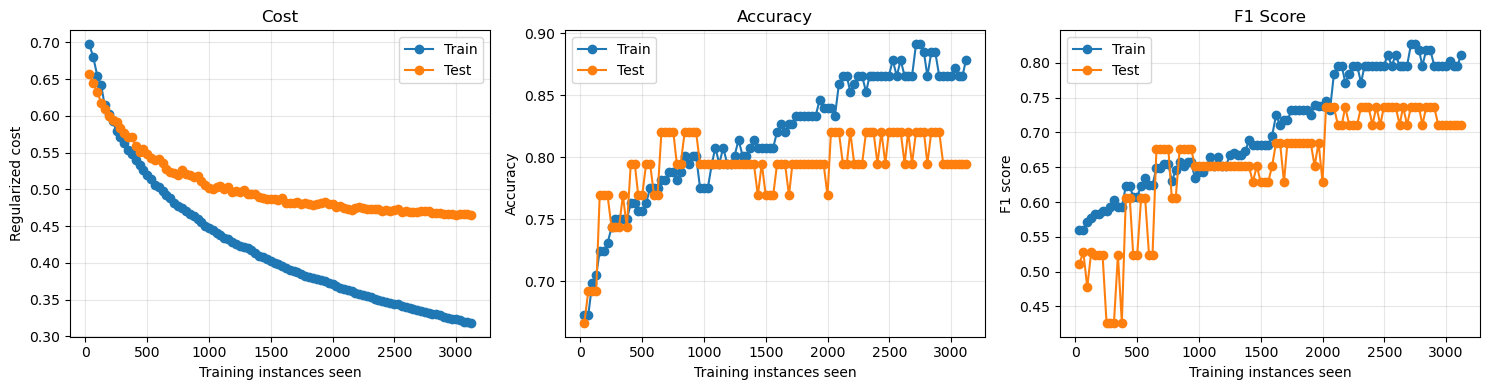

,iterations,batches,updates,train_instances_seen,train_cost,test_cost,train_accuracy,test_accuracy,train_f1,test_f1
99,20,5,100,3120,0.31857,0.465286,0.878205,0.794872,0.811054,0.711111


In [6]:
network = NeuralNetwork(num_hidden_layers=1, num_neurons_per_hidden_layer=8)
network.configure_for_fit(regularization_strength=0.01, step_size=0.3)
history = pd.DataFrame(network.fit(
    X_train_scaled, y_train, num_iterations=20, batch_size=32,
    random_seed=SEED, shuffle=True, verbose=False, record_history=True,
    X_test=X_test_scaled, y_test=y_test,
))
(RESULTS_DIR / 'NeuralNetwork').mkdir(exist_ok=True)
(FIGURES_DIR / 'NeuralNetwork').mkdir(exist_ok=True)
history.to_csv(RESULTS_DIR / 'NeuralNetwork' / 'history.csv', index=False)
figure, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, train_column, test_column, title, ylabel in zip(
        axes, ('train_cost', 'train_accuracy', 'train_f1'),
        ('test_cost', 'test_accuracy', 'test_f1'),
        ('Cost', 'Accuracy', 'F1 Score'),
        ('Regularized cost', 'Accuracy', 'F1 score')):
    axis.plot(history.train_instances_seen, history[train_column], marker='o', label='Train')
    axis.plot(history.train_instances_seen, history[test_column], marker='o', label='Test')
    axis.set_title(title)
    axis.set_xlabel('Training instances seen')
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend()
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'NeuralNetwork' / 'history_plot.png', bbox_inches='tight')
plt.show()
accuracy, f1 = metrics(y_test, network.predict_label(X_test_scaled))
pd.DataFrame([{'accuracy': accuracy, 'f1': f1}]).to_csv(RESULTS_DIR / 'NeuralNetwork' / 'test_metrics.csv', index=False)
history.tail(1)

## Interpretation

See [`docs/inductive-bias.md`](../docs/inductive-bias.md) for the discussion of the assumptions behind each algorithm and how they relate to the plots above. Multinomial Naive Bayes is intentionally not applied to these continuous biomedical features because its intended input is token/count data.